In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load the datasets
product=pd.read_csv("olist_products_dataset.csv")
items=pd.read_csv("olist_order_items_dataset.csv")
order=pd.read_csv("olist_orders_dataset.csv")
customer=pd.read_csv("olist_customers_dataset.csv")

In [3]:
# Merging the dataset
# 1. Joining products and items
pro_item=pd.merge(product,items,on="product_id",how="left")
pro_item.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,30-04-2018 17:33,10.91,7.39
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,06-02-2018 19:11,248.00,17.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,11-07-2018 21:30,79.80,7.82
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,07-08-2018 09:10,112.30,9.54
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,17-04-2018 01:30,37.90,8.29


In [4]:
#2. Joining orders to pro_item
sales_map=pd.merge(pro_item,order,on="order_id",how="left")
#3. Joining customer to above
sales_map=pd.merge(sales_map,customer,on="customer_id",how="left")

In [5]:
sales_map.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,...,delivered,24-04-2018 16:16,24-04-2018 19:04,25-04-2018 17:01,27-04-2018 16:42,09-05-2018 00:00,b1a1199364a4a7fe27c4486ab63f550d,13848,mogi-guacu,SP
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,...,delivered,31-01-2018 18:55,31-01-2018 19:11,05-02-2018 22:44,16-02-2018 13:27,22-02-2018 00:00,4b86049cb99e4aa774031daa9cd18f18,20551,rio de janeiro,RJ
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,...,delivered,09-07-2018 21:18,09-07-2018 21:30,10-07-2018 11:49,11-07-2018 23:24,18-07-2018 00:00,f63805d9c7edb84d92413af34b86a39c,5821,sao paulo,SP
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,...,delivered,03-08-2018 08:55,03-08-2018 09:31,03-08-2018 11:48,06-08-2018 15:14,08-08-2018 00:00,619e926d09b26efbd5180368b1ddc874,2018,sao paulo,SP
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,...,delivered,11-04-2018 01:06,11-04-2018 01:30,12-04-2018 22:56,13-04-2018 22:41,26-04-2018 00:00,ad353b4fb0e294adc4eda48af73e68a6,5835,sao paulo,SP
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0,c214058828b43a44f352b56ff2d5c0a5,...,delivered,12-03-2018 15:41,13-03-2018 15:48,14-03-2018 22:06,29-03-2018 18:39,17-04-2018 00:00,8b28d6ec6f6a9124310e82e5a55f35de,35430,ponte nova,MG
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0,9632facd8bd95315d63a23bf616d85b0,...,delivered,14-01-2018 12:31,14-01-2018 12:39,15-01-2018 21:56,19-01-2018 22:39,07-02-2018 00:00,f7495a8d48d05ca657eb075b905a1b8b,7093,guarulhos,SP
7,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0,c6343db6c1801f9c3301166f02931116,...,delivered,05-12-2017 11:14,05-12-2017 12:01,08-12-2017 20:46,18-12-2017 18:59,03-01-2018 00:00,3256bccea9c8aa521d29257b56c54f88,20540,rio de janeiro,RJ
8,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0,6ecf7023e8dd4ec8b08746c35b9fcb60,...,delivered,24-11-2017 14:22,24-11-2017 16:33,01-12-2017 20:55,07-12-2017 09:38,19-12-2017 00:00,8fe54925e8ff1067c803ae7026fe384b,9430,ribeirao pires,SP
9,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0,6ecf7023e8dd4ec8b08746c35b9fcb60,...,delivered,24-11-2017 14:22,24-11-2017 16:33,01-12-2017 20:55,07-12-2017 09:38,19-12-2017 00:00,8fe54925e8ff1067c803ae7026fe384b,9430,ribeirao pires,SP


In [6]:
# Simplifying the geolocation dataset so that we have one entry per zip code
geo=pd.read_csv("olist_geolocation_dataset.csv")
geo_clean=geo.groupby('geolocation_zip_code_prefix').agg({'geolocation_lat':'mean','geolocation_lng':'mean'}).reset_index()
geo_clean.head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733
5,1006,-23.550102,-46.636137
6,1007,-23.550046,-46.637251
7,1008,-23.546002,-46.635886
8,1009,-23.546835,-46.636491
9,1010,-23.546389,-46.635226


In [7]:
#4 Joiming sales_map to geo_clean
final_df=pd.merge(sales_map,geo_clean,left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='left')
final_df.head(10)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,...,25-04-2018 17:01,27-04-2018 16:42,09-05-2018 00:00,b1a1199364a4a7fe27c4486ab63f550d,13848,mogi-guacu,SP,13848.0,-22.339784,-46.924310
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,...,05-02-2018 22:44,16-02-2018 13:27,22-02-2018 00:00,4b86049cb99e4aa774031daa9cd18f18,20551,rio de janeiro,RJ,20551.0,-22.914391,-43.245699
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,...,10-07-2018 11:49,11-07-2018 23:24,18-07-2018 00:00,f63805d9c7edb84d92413af34b86a39c,5821,sao paulo,SP,5821.0,-23.667379,-46.751166
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,...,03-08-2018 11:48,06-08-2018 15:14,08-08-2018 00:00,619e926d09b26efbd5180368b1ddc874,2018,sao paulo,SP,2018.0,-23.495704,-46.629707
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,...,12-04-2018 22:56,13-04-2018 22:41,26-04-2018 00:00,ad353b4fb0e294adc4eda48af73e68a6,5835,sao paulo,SP,5835.0,-23.650256,-46.753725
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0,c214058828b43a44f352b56ff2d5c0a5,...,14-03-2018 22:06,29-03-2018 18:39,17-04-2018 00:00,8b28d6ec6f6a9124310e82e5a55f35de,35430,ponte nova,MG,35430.0,-20.410060,-42.898817
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0,9632facd8bd95315d63a23bf616d85b0,...,15-01-2018 21:56,19-01-2018 22:39,07-02-2018 00:00,f7495a8d48d05ca657eb075b905a1b8b,7093,guarulhos,SP,7093.0,-23.457896,-46.540663
7,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0,c6343db6c1801f9c3301166f02931116,...,08-12-2017 20:46,18-12-2017 18:59,03-01-2018 00:00,3256bccea9c8aa521d29257b56c54f88,20540,rio de janeiro,RJ,20540.0,-22.922556,-43.243901
8,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0,6ecf7023e8dd4ec8b08746c35b9fcb60,...,01-12-2017 20:55,07-12-2017 09:38,19-12-2017 00:00,8fe54925e8ff1067c803ae7026fe384b,9430,ribeirao pires,SP,9430.0,-23.700355,-46.396752
9,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0,6ecf7023e8dd4ec8b08746c35b9fcb60,...,01-12-2017 20:55,07-12-2017 09:38,19-12-2017 00:00,8fe54925e8ff1067c803ae7026fe384b,9430,ribeirao pires,SP,9430.0,-23.700355,-46.396752


In [8]:
final_df.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'order_id', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng'],
      dtype='str')

In [9]:
date_cols=['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    final_df[col]=pd.to_datetime(final_df[col],format='mixed')
final_df['order_purchase_timestamp'].head()

0   2018-04-24 16:16:00
1   2018-01-31 18:55:00
2   2018-09-07 21:18:00
3   2018-03-08 08:55:00
4   2018-11-04 01:06:00
Name: order_purchase_timestamp, dtype: datetime64[us]

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
final_df['order_month_year']=final_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [12]:
monthly_growth=final_df.groupby('order_month_year')['order_id'].nunique().reset_index()
monthly_growth.columns=['year_month','order_count']
monthly_growth

,year_month,order_count
0,2016-02,1
1,2016-03,8
2,2016-04,61
3,2016-05,43
4,2016-06,49
5,2016-07,45
6,2016-08,40
7,2016-09,27
8,2016-10,37
9,2016-12,1


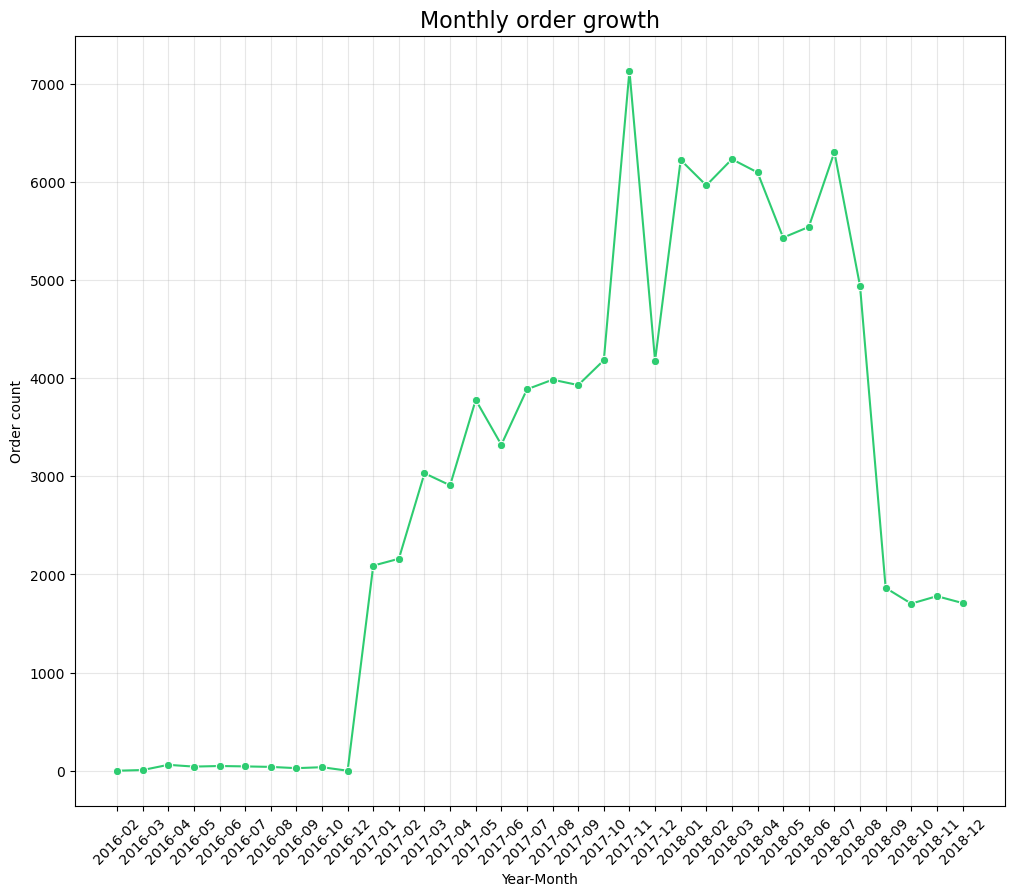

In [13]:
width=12
height=10
plt.figure(figsize=(width,height))
sns.lineplot(data=monthly_growth,x='year_month',y='order_count',marker='o',color='#2ecc71')
plt.title("Monthly order growth",fontsize=16)
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Order count")
plt.grid(True,alpha=0.3)
plt.show()
plt.close()

In [14]:
final_df.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'order_id', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'order_month_year'],
      dtype='str')

In [15]:
# Identifying the failing sellers

In [16]:
final_df['shipping_limit_date']=pd.to_datetime(final_df['shipping_limit_date'],format='mixed')

In [17]:
final_df['seller_shipping_delay']=(final_df['order_delivered_carrier_date']-final_df['shipping_limit_date']).dt.total_seconds()/86400
# flagging the late shipping sellers
final_df['is_shipping_delay']=final_df['seller_shipping_delay']>0
seller_performance=final_df.groupby('seller_id').agg({'order_id':'nunique','is_shipping_delay':'sum'}).reset_index()
# calcuating the late percentage
seller_performance['late_rate']=(seller_performance['is_shipping_delay']/seller_performance['order_id'])*100
top_late_sellers=seller_performance[seller_performance['order_id']>50].sort_values(by='late_rate',ascending=False)
top_late_sellers.head(10)

,seller_id,order_id,is_shipping_delay,late_rate
1747,8e6d7754bc7e0f22c96d255ebda59eba,85,71,83.529412
2451,ca3bd7cd9f149df75950150d010fe4a2,71,56,78.873239
1862,98dac6635aee4995d501a3972e047414,91,64,70.329670
2257,bbad7e518d7af88a0897397ffdca1979,69,46,66.666667
1669,88460e8ebdecbfecb5f9601833981930,248,163,65.725806
2039,a7f13822ceb966b076af67121f87b063,75,46,61.333333
333,1ca7077d890b907f89be8c954a02686a,115,70,60.869565
1032,54965bbe3e4f07ae045b90b0b8541f52,78,47,60.256410
415,23613d49c3ac2bd302259e55c06c050c,70,42,60.000000
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,98,58,59.183673


In [18]:
final_df.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'order_id', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'order_month_year', 'seller_shipping_delay', 'is_shipping_delay'],
      dtype='str')

In [19]:
final_df['delivery_time_delay']=(final_df['order_delivered_customer_date']-final_df['order_purchase_timestamp']).dt.days
# taking into considertion only those orders which have been delivered- not empty or NaN
delivered_orders=final_df.dropna(subset=['order_delivered_customer_date'])
delivered_orders['delivery_time_delay']

0           3.0
1          15.0
2          61.0
3          92.0
4        -205.0
          ...  
112645    -45.0
112646    -72.0
112647    -72.0
112648    -72.0
112649   -113.0
Name: delivery_time_delay, Length: 110196, dtype: float64

In [20]:
negative_count=(final_df['delivery_time_delay']>0).sum()
negative_count

np.int64(76476)

In [21]:
final_df_copy=final_df.copy()

In [22]:
final_df_copy=final_df_copy[(final_df_copy['delivery_time_delay']>=0) & (final_df_copy['delivery_time_delay']<=100)]
final_df_copy.dropna(subset=['order_delivered_customer_date'])


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,order_month_year,seller_shipping_delay,is_shipping_delay,delivery_time_delay
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,...,13848,mogi-guacu,SP,13848.0,-22.339784,-46.924310,2018-04,-5.022222,False,3.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,...,20551,rio de janeiro,RJ,20551.0,-22.914391,-43.245699,2018-01,-30.852083,False,15.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,...,5821,sao paulo,SP,5821.0,-23.667379,-46.751166,2018-09,-31.403472,False,61.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,...,2018,sao paulo,SP,2018.0,-23.495704,-46.629707,2018-03,-121.890278,False,92.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0,9632facd8bd95315d63a23bf616d85b0,...,7093,guarulhos,SP,7093.0,-23.457896,-46.540663,2018-01,-2.613194,False,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112638,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,4c460fdf49b517270b6258ba2d3c1ef9,...,6395,carapicuiba,SP,6395.0,-23.532326,-46.850225,2018-06,-5.195139,False,1.0
112639,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,6e4008bddce63615856554f94e5233db,...,8461,sao paulo,SP,8461.0,-23.559837,-46.404230,2018-06,-2.358333,False,5.0
112640,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,7c8a032bb75e0e4d524b14ba147d4ba5,...,20530,rio de janeiro,RJ,20530.0,-22.937686,-43.248869,2017-08,-3.024306,False,9.0
112642,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0,420937423f0cb3d3fe689330b5d385a9,...,25630,petropolis,RJ,25630.0,-22.524248,-43.161617,2017-10,-2.472917,False,7.0


In [23]:
# State wise average delivery time report
state_report=final_df_copy.groupby('customer_state').agg({'delivery_time_delay':'mean','freight_value':'mean','order_id':'nunique'}).reset_index()
state_report.columns=['state','avg delivery time','avg freight value','number orders']
state_report=state_report.sort_values(by='avg delivery time',ascending=False)
state_report.head()

,state,avg delivery time,avg freight value,number orders
1,AL,34.780702,36.356579,208
2,AM,33.288889,34.593778,78
20,RO,32.492308,40.661000,117
0,AC,31.555556,41.272444,37
3,AP,31.447368,30.775789,30


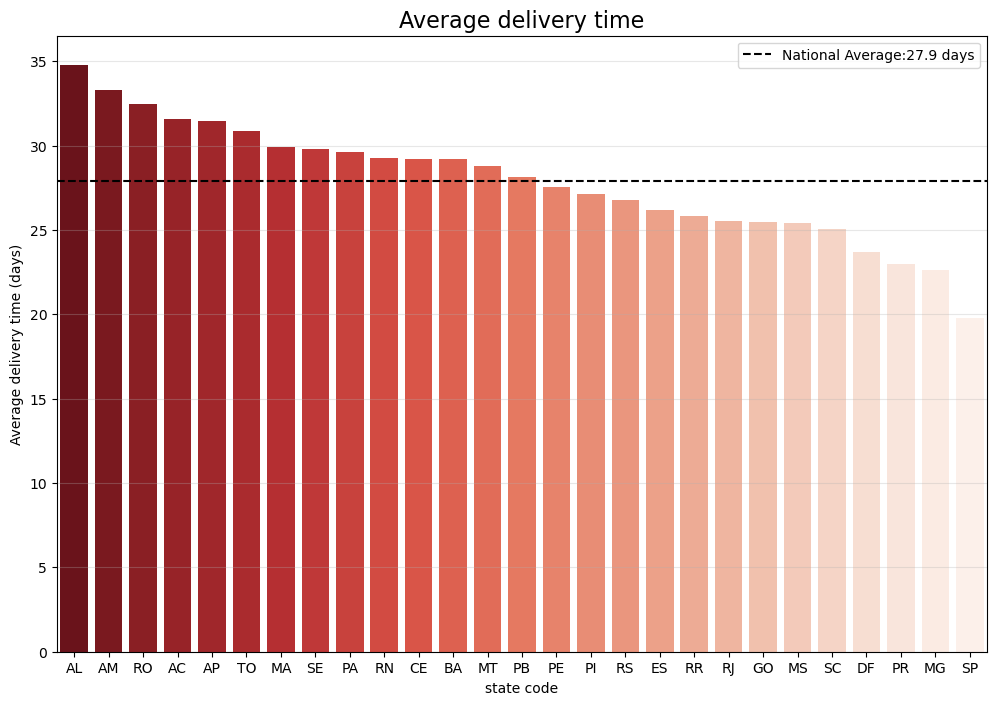

In [24]:
import seaborn as sns
plot_data=state_report.copy()
plt.figure(figsize=(12,8))
sns.barplot(data=plot_data,x='state',y='avg delivery time',hue='state',palette='Reds_r',legend=False)
national_avg=plot_data['avg delivery time'].mean()
plt.axhline(national_avg,color='black',linestyle='--',label=f'National Average:{national_avg:.1f} days')
plt.title('Average delivery time',fontsize=16)
plt.legend()
plt.xlabel('state code')
plt.ylabel('Average delivery time (days)')
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.close()

In [25]:
# Combining the final_df_copy and product_category_name_english_translation
product_category_name_trans=pd.read_csv("product_category_name_translation.csv")
final_df_copy=pd.merge(final_df_copy,product_category_name_trans,on='product_category_name',how='left')
final_df_copy.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'order_id', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'order_month_year', 'seller_shipping_delay', 'is_shipping_delay',
       'delivery_time_delay', 'product_category_name_english'],
      dtype='str')

In [26]:
# Product category analysis
cat_analysis=final_df_copy.groupby('product_category_name_english').agg({'delivery_time_delay':'mean','product_weight_g':'mean','order_id':'nunique'}).reset_index()
cat_analysis=cat_analysis[cat_analysis['order_id']>=100]
cat_analysis.columns=['product category name','avg delivery time','avg product weight(g)','number orders']
cat_analysis=cat_analysis.sort_values(by='avg delivery time',ascending=False)
cat_analysis

,product category name,avg delivery time,avg product weight(g),number orders
57,office_furniture,32.028221,11157.656442,622
54,market_place,28.102740,1230.390411,136
48,home_construction,27.401840,2598.573620,263
45,home_appliances_2,25.735537,9073.933884,120
70,watches_gifts,24.712969,553.155973,2723
40,furniture_living_room,24.594262,7816.639344,201
26,electronics,24.482784,865.021245,1248
10,books_technical,24.323308,1003.827068,128
15,computers_accessories,24.138968,841.814882,3311
47,home_confort,23.848039,2986.274510,187


In [27]:
# Calculating the correlation coefficient
corr_eff=cat_analysis[['avg delivery time','avg product weight(g)']].corr()
r_value=corr_eff.iloc[0,1]
print(f"The correlation coefficient value between delivery time and product weight is: {r_value:.2f}")

The correlation coefficient value between delivery time and product weight is: 0.33


In [28]:
final_df_copy.isnull().sum()

product_id                         0
product_category_name            747
product_name_lenght              747
product_description_lenght       747
product_photos_qty               747
product_weight_g                  12
product_length_cm                 12
product_height_cm                 12
product_width_cm                  12
order_id                           0
order_item_id                      0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  4
order_delivered_carrier_date       1
order_delivered_customer_date      0
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
geolocation_zip_code_prefix      136
g

In [29]:
final_df_copy.dropna(subset=['product_category_name_english','geolocation_lat','geolocation_lng','order_approved_at','order_delivered_carrier_date'],axis=0,inplace=True)

In [30]:
final_df_copy.dropna(subset=['product_category_name','product_name_lenght','product_description_lenght','product_photos_qty'],axis=0,inplace=True)

In [31]:
cols_to_fix=['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for col in cols_to_fix:
    median_value=final_df_copy[col].median()
    final_df_copy.replace(np.nan,median_value,inplace=True)
final_df_copy.isnull().sum()

product_id                       0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
order_id                         0
order_item_id                    0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
geolocation_zip_code_prefix      0
geolocation_lat                  0
geolocation_lng     

In [32]:
final_df_copy.info()

<class 'pandas.DataFrame'>
Index: 54728 entries, 0 to 55626
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   product_id                     54728 non-null  str           
 1   product_category_name          54728 non-null  str           
 2   product_name_lenght            54728 non-null  float64       
 3   product_description_lenght     54728 non-null  float64       
 4   product_photos_qty             54728 non-null  float64       
 5   product_weight_g               54728 non-null  float64       
 6   product_length_cm              54728 non-null  float64       
 7   product_height_cm              54728 non-null  float64       
 8   product_width_cm               54728 non-null  float64       
 9   order_id                       54728 non-null  str           
 10  order_item_id                  54728 non-null  int64         
 11  seller_id                      

In [33]:
# Investigating the list of variables/factors that have impact on our target variable(Delivery time delay)

In [34]:
raw_features=final_df_copy.drop(columns=['product_id', 'order_id', 'seller_id', 'customer_id', 
    'customer_unique_id', 'order_status', 'product_category_name',
    'shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'delivery_time_delay'])
raw_features.columns
                                

Index(['product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'order_item_id', 'price',
       'freight_value', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix', 'geolocation_lat',
       'geolocation_lng', 'order_month_year', 'seller_shipping_delay',
       'is_shipping_delay', 'product_category_name_english'],
      dtype='str')

In [35]:
x_all=pd.get_dummies(raw_features,drop_first=True,dtype=int)
y=final_df_copy['delivery_time_delay']

In [37]:
from sklearn.ensemble import RandomForestRegressor
df_sample=final_df_copy.sample(n=10000,random_state=42)
random_sample_features=df_sample.drop(columns=[
    'product_id', 'order_id', 'seller_id', 'customer_id', 
    'customer_unique_id', 'order_status', 'product_category_name',
    'shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'delivery_time_delay'
])
x_sample=pd.get_dummies(random_sample_features,drop_first=True,dtype=int)
y_sample=df_sample['delivery_time_delay']
forest_light=RandomForestRegressor(n_estimators=50,random_state=42,n_jobs=-1)
forest_light.fit(x_sample,y_sample)
importances=pd.Series(forest_light.feature_importances_,index=x_sample.columns)
print(importances.sort_values(ascending=False).head(10))

seller_shipping_delay          0.304265
freight_value                  0.051826
geolocation_lat                0.042087
price                          0.037087
product_description_lenght     0.036036
customer_zip_code_prefix       0.033502
geolocation_lng                0.032212
geolocation_zip_code_prefix    0.031919
product_name_lenght            0.028358
product_weight_g               0.027677
dtype: float64


By moving beyond intuition and utilizing Algorithmic Feature Selection, it is found out that 30% of delivery delays are rooted 
in the pre-shipping phase (about 30.4% seller shipping delay). This data-driven insight allows the business to shift focus from expensive logistics upgrades to targeted seller performance management.

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
features_consider=['seller_shipping_delay','freight_value','geolocation_lat','geolocation_lng','price','product_weight_g']
x=final_df_copy[features_consider]
y=final_df_copy['delivery_time_delay']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
lnr=LinearRegression()
lnr.fit(x_train,y_train)
y_pred=lnr.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
rsquare=r2_score(y_test,y_pred)
print(f"---Model peformance---")
print(f"Mean absolute error is {mae:.2f} days")
print(f"R square value is {rsquare:.4f}")

---Model peformance---
Mean absolute error is 19.40 days
R square value is 0.0484


In [ ]:
# USing random forest regressor as a model

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
x_train,x_test,y_train,y_test=train_test_split(X_final,y_final,test_size=0.2,random_state=42)
rf_model=RandomForestRegressor(n_estimators=100,max_depth=20,random_state=42,n_jobs=-1)
rf_model_train=rf_model.fit(x_train,y_train)
y_pred_rf_model=rf_model_train.predict(x_test)
mae=mean_absolute_error(y_test,y_pred_rf_model)
r2score=r2_score(y_test,y_pred_rf_model)
print(f"mean absolute error:{mae:.2f} days")
print(f"r square score:{r2score:.4f}")


mean absolute error:13.19 days
r square score:0.3776


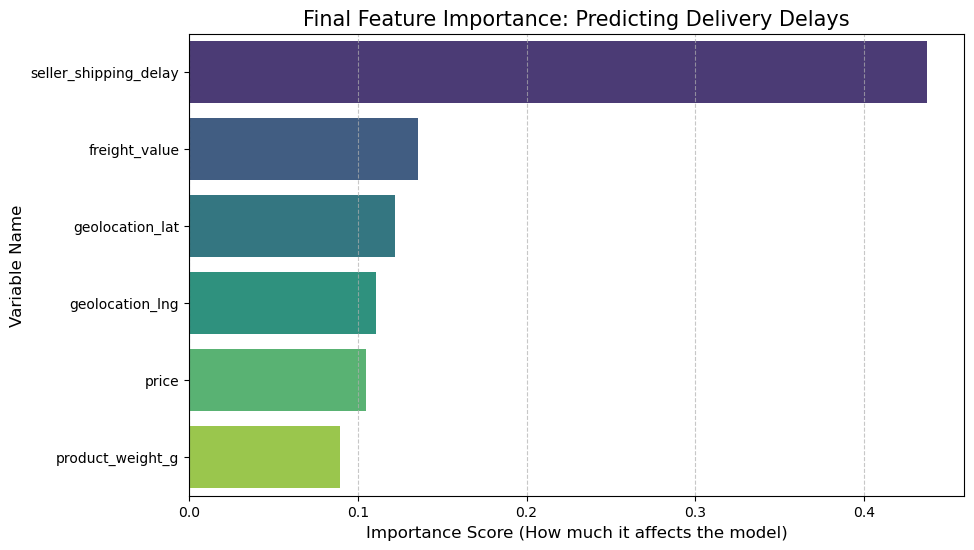

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = x_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature',palette='viridis',legend=False)

plt.title('Final Feature Importance: Predicting Delivery Delays', fontsize=15)
plt.xlabel('Importance Score (How much it affects the model)', fontsize=12)
plt.ylabel('Variable Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [55]:
final_df_copy.to_csv('olist_final_data.csv',index=False)

In [57]:
final_df_copy.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_item_id,shipping_limit_date,price,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,seller_shipping_delay,delivery_time_delay
count,54728.000000,54728.000000,54728.000000,54728.000000,54728.000000,54728.000000,54728.000000,54728.000000,54728,54728.000000,...,54728,54728,54728,54728,54728.000000,54728.000000,54728.000000,54728.000000,54728.000000,54728.000000
mean,48.808471,783.495030,2.217110,2043.296576,29.973286,16.354024,22.852909,1.203095,2018-01-20 09:24:51.256761,117.675270,...,2018-01-06 21:51:51.929908,2018-01-13 17:34:43.063879,2018-01-30 07:17:58.262315,2018-02-05 18:21:39.283730,33370.753855,33370.753855,-21.409452,-46.241307,-6.659817,22.915107
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,2016-10-10 15:50:00,0.850000,...,2016-04-10 10:28:00,2016-01-11 07:27:00,2016-03-11 10:58:00,2016-01-12 00:00:00,1003.000000,1003.000000,-33.689948,-72.668881,-473.140972,0.000000
25%,42.000000,345.000000,1.000000,284.000000,18.000000,8.000000,15.000000,1.000000,2017-09-19 21:04:45,39.650000,...,2017-09-14 09:46:15,2017-09-18 21:07:00,2017-10-08 20:48:45,2017-09-20 00:00:00,9280.000000,9280.000000,-23.596003,-47.945086,-5.985417,6.000000
50%,52.000000,602.000000,1.000000,650.000000,25.000000,13.000000,20.000000,1.000000,2018-02-04 03:49:00,71.000000,...,2018-01-26 14:59:00,2018-02-02 00:30:30,2018-02-23 16:06:30,2018-03-08 00:00:00,22451.000000,22451.000000,-22.967674,-46.635032,-3.195139,11.000000
75%,57.000000,982.000000,3.000000,1750.000000,37.000000,20.000000,30.000000,1.000000,2018-06-15 14:56:15,129.990000,...,2018-05-16 10:12:00,2018-05-25 00:45:30,2018-06-13 14:14:00,2018-07-05 00:00:00,54105.000000,54105.000000,-20.431710,-43.917779,-0.839583,30.000000
max,76.000000,3985.000000,19.000000,40425.000000,105.000000,105.000000,118.000000,21.000000,2018-12-09 13:24:00,6729.000000,...,2018-12-07 04:10:00,2018-12-07 15:57:00,2018-12-09 20:15:00,2018-12-09 00:00:00,99980.000000,99980.000000,42.184003,-8.723762,444.429167,100.000000
std,10.062663,647.347539,1.720563,3685.034547,16.002347,13.262004,11.594752,0.725097,NaN,178.643006,...,NaN,NaN,NaN,NaN,29690.447820,29690.447820,5.368285,3.899905,70.819165,25.794996


In [63]:
final_df_copy.info()

<class 'pandas.DataFrame'>
Index: 54728 entries, 0 to 55626
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   product_id                     54728 non-null  str           
 1   product_category_name          54728 non-null  str           
 2   product_name_lenght            54728 non-null  float64       
 3   product_description_lenght     54728 non-null  float64       
 4   product_photos_qty             54728 non-null  float64       
 5   product_weight_g               54728 non-null  float64       
 6   product_length_cm              54728 non-null  float64       
 7   product_height_cm              54728 non-null  float64       
 8   product_width_cm               54728 non-null  float64       
 9   order_id                       54728 non-null  str           
 10  order_item_id                  54728 non-null  int64         
 11  seller_id                      